In [1]:
from sklearn.datasets import make_blobs, make_classification

from imblearn.under_sampling import EditedNearestNeighbours, TomekLinks
from imblearn.over_sampling import SMOTE

In [2]:
import imblearn.under_sampling

In [3]:
for item in dir(imblearn.under_sampling):
    if 'neighbour' in item.lower():
        print(item)

CondensedNearestNeighbour
EditedNearestNeighbours
NeighbourhoodCleaningRule
RepeatedEditedNearestNeighbours


In [4]:
import imblearn

In [5]:
dir(imblearn)

['FunctionSampler',
 'LazyLoader',
 '__IMBLEARN_SETUP__',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_version',
 'base',
 'combine',
 'ensemble',
 'exceptions',
 'importlib',
 'keras',
 'metrics',
 'over_sampling',
 'pipeline',
 'show_versions',
 'sys',
 'tensorflow',
 'types',
 'under_sampling',
 'utils']

In [6]:
import imblearn.combine


In [7]:
dir(imblearn.combine)

['SMOTEENN',
 'SMOTETomek',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_smote_enn',
 '_smote_tomek']

In [8]:
from imblearn.combine import SMOTEENN, SMOTETomek

# Creating the data

In [9]:
import sys
sys.path.append('../')

In [10]:
import my_functions

In [11]:
from my_functions import MakeData

In [12]:
?MakeData

Signature: MakeData(n_classes=2, weights=[0.99], sep=1)
Docstring:
Ex: 

>>>X,y = MakeData(n_classes=2, weights=[0.90], sep=2)
File:      ~/Udemy/Udemy/machine_learning_imbalanced_data/my_functions.py
Type:      function

<Axes: xlabel='varA', ylabel='varB'>

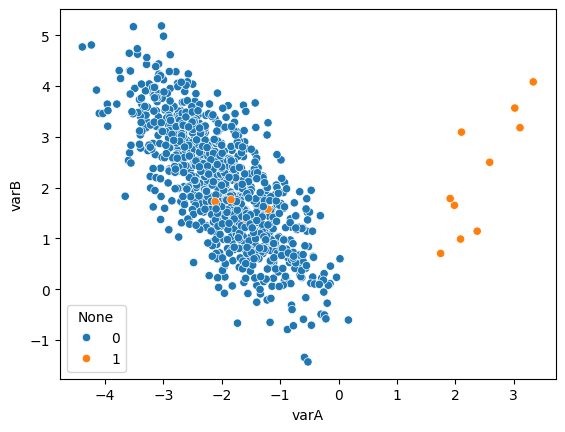

In [17]:
X,y = MakeData(sep=2)
sns.scatterplot(data=X, x='varA', y='varB', hue=y)

# SMOTEENN and SMOTEETomek

In [20]:
sm = SMOTE(sampling_strategy='auto', random_state=0, k_neighbors=5)
X_sm, y_sm = sm.fit_resample(X,y)

In [37]:
enn = EditedNearestNeighbours(
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=-1,
)

smenn = SMOTEENN(
    sampling_strategy='auto',
    random_state=0,
    smote=sm,
    enn=enn,
    n_jobs=-1,
)

X_smenn, y_smenn = smenn.fit_resample(X,y)

In [39]:
tl = TomekLinks(sampling_strategy='auto', n_jobs=-1)

In [41]:
smtomek = SMOTETomek(
    sampling_strategy='auto',
    random_state=0,
    smote=sm,
    tomek=tl,
    n_jobs=-1,
)

X_smtl, y_smtl = smtomek.fit_resample(X,y)

In [42]:
X_sm.shape, X_smenn.shape, X_smtl.shape

((1968, 2), (1859, 2), (1953, 2))

In [43]:
y.value_counts(), y_sm.value_counts(), y_smenn.value_counts(), y_smtl.value_counts()

(0    984
 1     16
 Name: count, dtype: int64,
 0    984
 1    984
 Name: count, dtype: int64,
 0    984
 1    875
 Name: count, dtype: int64,
 0    984
 1    969
 Name: count, dtype: int64)

In [44]:
from my_functions import Scatterplot

In [45]:
?Scatterplot

Signature: Scatterplot(data1, class1, data2, class2, alpha=None)
Docstring:
Plot 2 Scatterplots.
1 Row and 2 columns, given the 2 provided datasets
Ex:

Without alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled)

With alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled, alpha=0.5)
File:      ~/Udemy/Udemy/machine_learning_imbalanced_data/my_functions.py
Type:      function

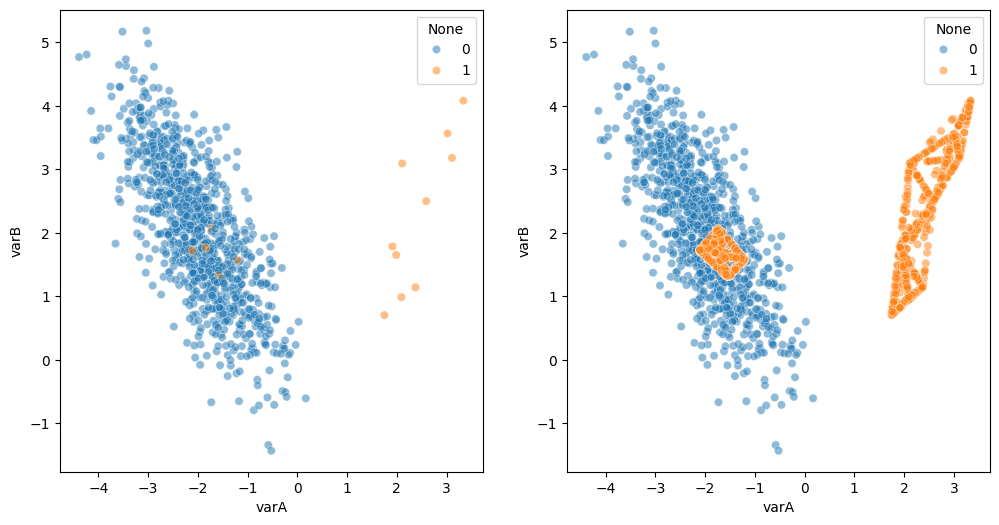

In [46]:
Scatterplot(X, y, X_sm, y_sm, alpha=0.5)

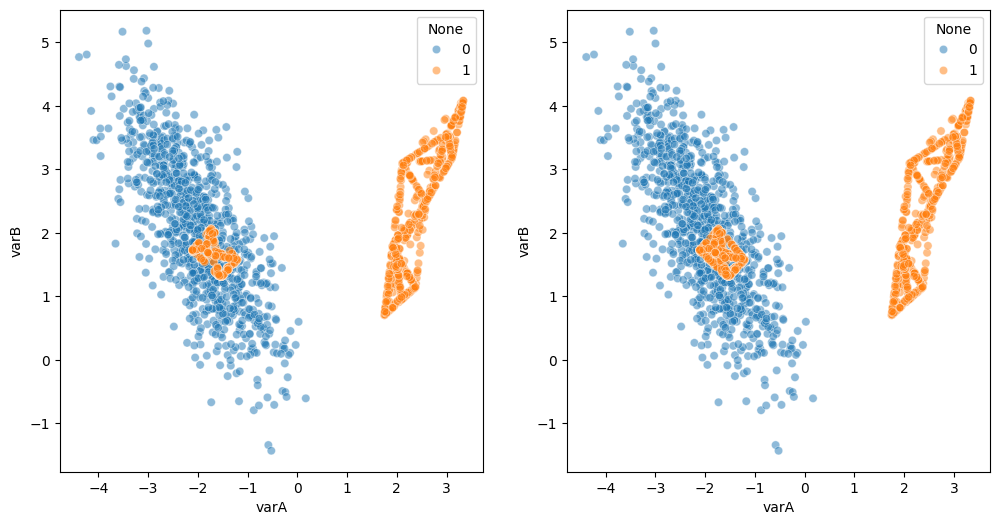

In [47]:
Scatterplot(X_smenn, y_smenn, X_smtl, y_smtl, alpha=0.5)

In [ ]:
X_sm.shape, X_smenn.shape, X_smtl.shape